# Classification RNN Models - Augmented

Generated from `DELE_CA1_B.ipynb` by `scripts/split_notebook.py`.


---
# 5. Classification RNN Model Trainings - (Augmented)

In this section, we will be training the various Classification models for the RNN to predict the Sentiment of the Movie Review (either Positive, Negative or Neutral). This will subsequently be evaluated alongside the Regression Models to determine which one performs the best and which RNN Model in particular.

---
## 5.1 SimpleRNN Classification Model

In this sub-section, we will be training the SimpleRNN Classification Model. As the name suggests, this is the most simple RNN Model there is and may serve as a baseline of comparison for the other Model. However, if this Model does perform well, it can be used as one of the Final Model if Classification is decided to be the chosen method of output. The relevant formulas are indicated below:

---
**Hidden State Update**
$$
h_t = \tanh(W_{xh}x_t + W_{hh}h_{t-1} + b_h)
$$
Where:
- $h_t$: Current Hidden State

- $x_t$: Input at Time $t$

- $h_{t-1}$: Previous Hidden State

- $W_{xh}$: Weight Matrix from Input to Hidden

- $W_{hh}$: Weight Matrix From Hidden to Hidden

- $b_h$: Bias Term

- $\tanh$: Activation Function Applied Element-wise

---
**Output at Each Time Step**
$$
y_t = W_{hy}h_t + b_y
$$
Where:
- $y_t$: Output at Time $t$

- $W_{hy}$: Weight Matrix from Hidden to Output

- $b_y$: Output Bias

---
**Loss Function (Classification)**
$$
\hat{y} = \text{softmax}(Wh_T + b)
$$
Calculated Using:
$$
\mathcal{L} = -\sum_{i=1}^{C} y_i \log(\hat{y}_i)
$$
Where:
- $C$: Number of Classes

- $y_i$: True One-hot Label

- $\hat{y}_i$: Predicted Probability for Class $i$

---
**Backpropagation Through Time (BPTT)**
$$
\frac{\partial \mathcal{L}}{\partial W} = \sum_{t=1}^{T} \frac{\partial \mathcal{L}}{\partial h_t} \cdot \frac{\partial h_t}{\partial W}
$$
Where:
- $\mathcal{L}$: Total loss over all time steps

- $W$:	Any trainable weight matrix (e.g., $W_{xh}$, $W_{hh}$)

- $T$:	Total number of time steps in the input sequence

- $t$:	Current time step in the unrolled RNN

- $h_t$:	Hidden state at time step $t$

- $\frac{\partial \mathcal{L}}{\partial W}$:	Gradient of the loss with respect to weights $W$

- $\frac{\partial \mathcal{L}}{\partial h_t}$:	Gradient of the loss with respect to hidden state $h_t$

- $\frac{\partial h_t}{\partial W}$:	Gradient of hidden state $h_t$ with respect to weight $W$

---

With all the essential Formulas for SimpleRNN indicated, we will proceed to the Modeling in this sub-section.

---
### 5.1.1 Defining Callbacks

In this sub-section, we will be pre-defining the various Callbacks. This is to ensure consistency throughout the model and also to increase the Model Accuracy and optimise the Computation Cost for training each model. These Callbacks will be main used during the Keras Tuner in the next sub-section. The formulas and logic for these Callbacks are indicated below:

---
**Learning Rate Scheduler:**

Purpose: Reduces Learning Rate During Training to Fine-tune Model Convergence.

$$\text{If } epoch \mod 10 = 0 \Rightarrow \eta_{new} = \frac{1}{2} \cdot \eta$$

Where:

- $\eta$ = current learning rate

- $\eta_{\text{new}}$ = updated learning rate

- $epoch \bmod 10$ checks if the epoch is a multiple of 10

---
**ReduceLROnPlateau:**

Purpose: Automatically Reduces the Learning Rate when Validation Performance Plateaus.

$$
\text{If no improvement in } val\_loss \text{ for 3 epochs: } \eta_{\text{new}} = 0.5 \cdot \eta
$$

Where:

- $\eta_{\text{new}}$ = reduced learning rate

---
**EarlyStopping:**

Purpose: Prevents Wastage of Computational Power if Model Does Not Improve.

$$
\text{If } val\_loss \text{ does not improve for 10 epochs, stop training and restore best weights}
$$

---
With the formulas and Various Callbacks listed, we will proceed to Defind the Callbacks in the Code Cell below in preparation for Model Training.

In [ ]:
# ======================== Defining Learning Rate Scheduler ======================== #
def scheduler(epoch, lr):
    if epoch % 10 == 0 and epoch:
        return lr * 0.5
    return lr

# ======================== Defining Callbacks ======================== #
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
lr_scheduler = LearningRateScheduler(scheduler)

With reference to the Code Cell above, we are able to identify that that the Callbacks have been successfully defined and the various parameters are set so as to ensure a high accuracy model training.

---
### 5.1.2 Defining Model Parameters

In this sub-section, we will be defining the Model's Parameters that will be tuned using Keras Tuner. There are various Parameters and Characteristics within the Code Cell below. All of these Parameters and their purpose have been indicated below:

---
Embedding Layer
$$
x_t^{(emb)} = E[x_t]
$$
Where:
- $x_t$: token index at time $t$  
- $E$: embedding matrix (learned)

---
Recurrent Hidden State
$$
h_t = \tanh(W_{xh}x_t^{(emb)} + W_{hh}h_{t-1} + b_h)
$$
Where:
- $h_t$: current hidden state  
- $x_t^{(emb)}$: embedded input at time $t$  
- $W_{xh}$: input-to-hidden weights  
- $W_{hh}$: hidden-to-hidden weights  
- $b_h$: hidden bias

---
Dense Layer
$$
z = \text{ReLU}(W_d h_t + b_d)
$$
Where:
- $z$: output of dense hidden layer  
- $W_d$: weights from RNN output to dense  
- $b_d$: bias for dense layer

---
Output Layer (Softmax)
$$
\hat{y} = \text{softmax}(W_o z + b_o)
$$
Where:
- $\hat{y}$: predicted class probabilities  
- $W_o$: weights from dense to output  
- $b_o$: output bias

---
Loss Function (Sparse Categorical Crossentropy)
$$
\mathcal{L} = -\log(\hat{y}_{true})
$$
Where:
- $\hat{y}_{true}$: predicted probability of the true class

---
With all the relevant Formulas indicated, we will proceed to define the Model's Hyperparameter in the Code Cell below.

In [ ]:
def build_rnn_model(hp):
    model = Sequential()

    # ----- Input Layer ----- #
    model.add(Input(shape=(X_train_class_pad.shape[1],)))

    # ----- Embedding Layer ----- #
    model.add(Embedding(
        input_dim=10000,
        output_dim=hp.Choice("embed_dim", [128, 256, 300]),
        embeddings_initializer='uniform'
    ))

    # ----- 1st Bidirectional SimpleRNN Layer ----- #
    model.add(Bidirectional(SimpleRNN(
        units=hp.Choice("rnn_units_1", [128, 256, 384]),
        return_sequences=True,
        activation='tanh',
        kernel_regularizer=l2(0.001)
    )))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_rnn_1", 0.3, 0.5, step=0.1)))

    # ----- 2nd Bidirectional SimpleRNN Layer ----- #
    model.add(Bidirectional(SimpleRNN(
        units=hp.Choice("rnn_units_2", [64, 128]),
        return_sequences=False,
        activation='tanh',
        kernel_regularizer=l2(0.001)
    )))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_rnn_2", 0.3, 0.5, step=0.1)))

    # ----- Dense Layer 1 ----- #
    model.add(Dense(
        units=hp.Choice("dense_units_1", [128, 256]),
        kernel_regularizer=l2(0.001)
    ))
    model.add(LeakyReLU(alpha=0.1))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_dense_1", 0.3, 0.5, step=0.1)))

    # ----- Dense Layer 2 ----- #
    model.add(Dense(
        units=hp.Choice("dense_units_2", [64, 128]),
        kernel_regularizer=l2(0.001)
    ))
    model.add(LeakyReLU(alpha=0.1))
    model.add(Dropout(hp.Float("dropout_dense_2", 0.3, 0.5, step=0.1)))

    # ----- Output Layer (Binary Classification) ----- #
    model.add(Dense(1, activation='sigmoid'))

    # ----- Compile Model ----- #
    lr = hp.Choice("lr", [5e-4, 1e-4, 5e-5])
    optimiser = Adam(learning_rate=lr)

    model.compile(
        optimizer=optimiser,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

With reference to the Code Cell above, we are able to confirm that the Function for Creating a New Model for the Classification have been successfully defined and it can be utilised for the Keras Tuner.

---
### 5.1.3 Setting Up Keras Tuner

In this sub-section, we will be setting up the Keras Tuner which will be later utilised to find the best hyperparameter for the RNN Model. Setting up the Keras Tuner appropriately will also ensure that the Random Search do not need to be reruned again as a directory can be set up to link the saved Searches from the Google Drive. This will save up Computational Cost and ensure a more efficient and consistent rerun of Codes should the need arise. To allow for replication, the Seed will be set to 42. However, due to varying Computational Capabilities of different GPUs and/or TPUs, a slight deviation will be normal in the various Evaluation Metrics despite having the same Seed.

In [ ]:
# ======================== Setting Up Keras Tuner ======================== #
tuner = kt.RandomSearch(
    build_rnn_model,
    objective='val_accuracy',
    max_trials=20,
    executions_per_trial=1,
    directory='Tunings',
    project_name='tuner_rnn_classification',
    overwrite=False,
    seed=42
)

Reloading Tuner from Tunings/tuner_rnn_classification/tuner0.json


With reference to the Code Cell above, we are able to verify that the Keras Tuner have been established correctly with the directory defined successfully too. We shall move on to conduct the Random Search using the Keras Tuner.

---
### 5.1.4 Conducting Keras Tuner Random Search

In this sub-section, we will be conducting the Random Search to find the best Hyperparameter for the RNN Model using the Keras Tuner. Unlike traditional AIML, there will only be a Random Search and no Grid Search due to the extremely high Computational Resources Require to run a Grid Search for Deep Learning. It is also important to note that the Hyperparameter Random Search will take a long duration due to the nature of the Deep Learning.

In [ ]:
# ======================== Tuning Hyperparameters ======================== #
tuner.search(
    X_train_class_pad,
    y_train_class,
    validation_data=(X_val_class_pad, y_val_class),
    epochs=100,
    callbacks=[early_stop, reduce_lr, lr_scheduler],
    verbose=2
)

With reference to the output above, we are able to see that the best Validation Accuracy have been obtained. As the data from the search have been saved, we will not have to rerun the Keras Tuner for this Model again.

---
### 5.1.5 Obtaining Best Hyperparameter

In this sub-section, we will be obtaining the Best Hyperparameter from the Keras Tuner Random Search so as to prepare for the training of the RNN Model in the next sub-section.

In [ ]:
# ======================== Retrieve Best Model ======================== #
best_hp_srnn_class = tuner.get_best_hyperparameters(1)[0]
model_srnn_class_best = tuner.hypermodel.build(best_hp_srnn_class)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning:

Argument `alpha` is deprecated. Use `negative_slope` instead.



With reference to the Code Cell above, we are able to confirm that the Best Hyperparameter have been obtained and the Model Architecture have been successfully built.

---
### 5.1.6 RNN Model Checkpoint

In this sub-section, we will be establishing the Model Checkpoint and saving the Model to our Google Drive. It is extremely important to take note that we will only be saving the Best Model so as to prevent excessive storage usage. The key monitor that will be used is the Validation Accuracy so as to achieve the Ideal Fit when placed together with the Validation Data. We will also be only saving the Best Model so as to prevent excessive space usage.

In [ ]:
# ======================== Model Checkpointing ======================== #
model_dir = "/content/drive/MyDrive/Colab Notebooks/DELE CA1 B/Models"
os.makedirs(model_dir, exist_ok=True)

checkpoint = ModelCheckpoint(
    filepath=os.path.join(model_dir, "srnn_classification_model.keras"),
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False
)

With reference to the Code Cell above, we are able to confirm that the Model have been saved successfully to the Google Drive and the Model is ready for Deployment should the need arise.

---
### 5.1.7 Training of RNN Model

In this sub-section, we will be training the Best RNN Model using the extracted Hyperparameter. This will subsequently allow us to obtain the Model's History which can allow us to conduct various visualisations such as plotting out the Learning Curves to identify the fitting of the Model.

In [ ]:
# ======================== Training Best Model ======================== #
history_rnn_best = model_srnn_class_best.fit(
    X_train_class_pad, y_train_class,
    validation_data=(X_val_class_pad, y_val_class),
    epochs=50,
    callbacks=[early_stop, reduce_lr, lr_scheduler, checkpoint],
    verbose=2
)

Epoch 1/50
41/41 - 22s - 529ms/step - accuracy: 0.5161 - loss: 2.1571 - val_accuracy: 0.2500 - val_loss: 2.1469 - learning_rate: 5.0000e-04
Epoch 2/50
41/41 - 2s - 42ms/step - accuracy: 0.6035 - loss: 1.9753 - val_accuracy: 0.7857 - val_loss: 1.8873 - learning_rate: 5.0000e-04
Epoch 3/50
41/41 - 1s - 34ms/step - accuracy: 0.8443 - loss: 1.5888 - val_accuracy: 0.2500 - val_loss: 3.5495 - learning_rate: 5.0000e-04
Epoch 4/50
41/41 - 1s - 34ms/step - accuracy: 0.9862 - loss: 1.2827 - val_accuracy: 0.5357 - val_loss: 1.9513 - learning_rate: 5.0000e-04
Epoch 5/50
41/41 - 1s - 35ms/step - accuracy: 0.9954 - loss: 1.2419 - val_accuracy: 0.7857 - val_loss: 1.6803 - learning_rate: 5.0000e-04
Epoch 6/50
41/41 - 2s - 40ms/step - accuracy: 0.9992 - loss: 1.2015 - val_accuracy: 0.9286 - val_loss: 1.3723 - learning_rate: 5.0000e-04
Epoch 7/50
41/41 - 1s - 35ms/step - accuracy: 0.9992 - loss: 1.1748 - val_accuracy: 0.2500 - val_loss: 6.1064 - learning_rate: 5.0000e-04
Epoch 8/50
41/41 - 1s - 35ms/ste

With reference to the output of the Code Cell above, we are able to infer that the Sequential Model have been successfully trained and will now be ready for Model Evaluation and Model Deployment on the Test Dataset.

---
### 5.1.8 Saving of Model Weights, Model Architecture and Model Tunings

In this sub-section, we will be Saving the Model's Weights into our Google Drive as per the expectaions of the Assessment. The weight will be saved in 'h5' format and will be submitted. The Tunings Record and the Model Architecture will also be saved so as to prevent the need for re-running all the previous codes which will be extremely Computationally Expensive.

In [ ]:
# ==================== Copy Results Back to Drive ==================== #
model_srnn_class_best.save_weights("Weights/weights_class_srnn_tuned.weights.h5")

shutil.copytree('Tunings',
                os.path.join(DRIVE_ROOT, 'Tunings'),
                dirs_exist_ok=True)

shutil.copytree('Models',
                os.path.join(DRIVE_ROOT, 'Models'),
                dirs_exist_ok=True)

shutil.copytree('Weights',
                os.path.join(DRIVE_ROOT, 'Weights'),
                dirs_exist_ok=True)

With reference to the Code Cell above, we are able to verify that the RNN Model's Weight have been saved successfully to the Google Drive.

---
### 5.1.9 Model Evaluations

In this sub-section, we will be evaluating the RNN Model's Performance on the Movie Reviews. We will not be evaluating solely based of the Model's Accuracy, but also based of it's Learning Curve and Specific Class Accuracy. This is to ensure that the Model is able to perform well at a hollistic level and not just solely based of Accuracy or Class Imbalanced Accuracy. More details will be established for the various Evaluations.

---
#### 5.1.9.1 Plotting of Learning Curve

In this sub-section, we will be plotting the Learning Curve to identify the Learning Capabilities of the RNN Model. This will allow us to identify if the Model is Underfitting, Overfitting or have attained the Ideal Fit. Should the RNN Model be Underfitting, it means that the RNN Model is failing to identify and learn the various patterns of the text. Should the RNN Model be Overfitting, it means that the Model has attained a High Accuracy solely based of Memorising the Data instead of Learning the Data's Attributes. However, if the RNN Model has a Ideal Fit it is a very good indicator that the RNN Model has Learnt from the Training Data. The Potential Observations and subsequent Action Plans are indicated below:

**Under Fitting Learning Curve**
- Re-run Keras Tuner to get Better Hyperparameters
- Adjust the Patience of Early Stopping
- Adjust the Number of Epochs to Obtain Better Learning Rate

**Over Fitting Learning Curve**
- Re-run Keras Tuner to get Better Hyperparameters
- Adjust the Patience of Early Stopping
- Adjust the Number of Epochs to Obtain Better Learning Rate

**Ideal Fitting Learning Curve**
- Accept the Hyperparameter
- Deploy the Model on Testing Data

With the Potential Observations and Action Plan listed, we will proceed to plot out the Learning Curve in the Code Cell below.

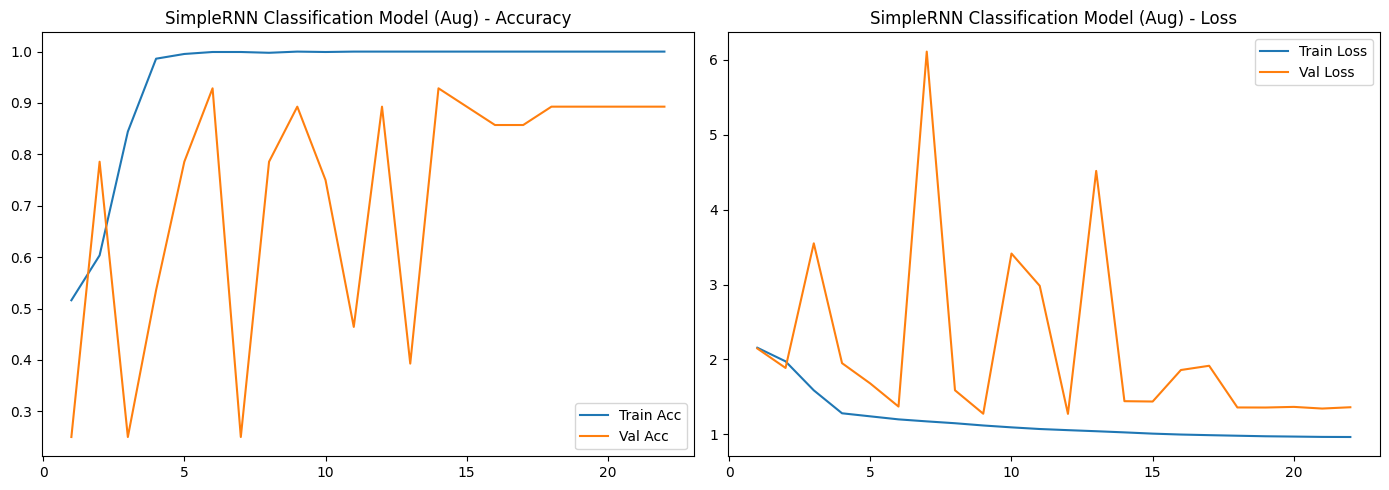

In [ ]:
# ======================== Plotting Training History ======================== #
def plot_history(history, title="SimpleRNN Classification Model (Aug)"):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Acc')
    plt.plot(epochs_range, val_acc, label='Val Acc')
    plt.title(f'{title} - Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Val Loss')
    plt.title(f'{title} - Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history_rnn_best)

With reference to the output of the Learning Curve above, we are able to see that the RNN Model has achieved a **Ideal Learning Curve**. This means that the RNN Model has indeed learnt from the Training Dataset instead of Memorising or Not Learning at all. With this observation stated, we will now proceed to View the Hyperparameter of the RNN Model and subsequently, Deploy the RNN Model on the Testing Data to get the final Evaluation Metrics.

---
#### 5.1.9.2 Model Hyperparameter

In this sub-section, we will be extracting out the rnn Model's Hyperparameter so as to display the current and Best Hyperparameter for future references within the Project. It is important to take note that the Hyperparameter may be different for other users of the code due to the varying Computational Environment.

In [ ]:
# ======================== Extracting Hyperparameters Into A Dictionary ======================== #
best_hps_dict = best_hp_srnn_class.values

# ======================== Creating of DataFrame ======================== #
hp_df = pd.DataFrame(list(best_hps_dict.items()), columns=['Hyperparameter', 'Value'])

# ======================== Displaying of DataFrame ======================== #
hp_df.style.background_gradient(cmap="Blues")

,Hyperparameter,Value
0,embed_dim,256.000000
1,rnn_units_1,256.000000
2,dropout_rnn_1,0.500000
3,rnn_units_2,128.000000
4,dropout_rnn_2,0.400000
5,dense_units_1,256.000000
6,dropout_dense_1,0.300000
7,dense_units_2,64.000000
8,dropout_dense_2,0.300000
9,lr,0.000500


With reference to the output of the DataFrame above, we are able to view the various parameters of the RNN Model and we are able to identify the various layers and neurons that makes up the Hidden Layer of the RNN Model.

---
#### 5.1.9.3 Model Deployment on Testing Data

In this sub-section, we will be Deploying our RNN Model on the Testing Data provided. Through the Deployment, we are able to obtain a Test Accuracy Metric and also the Test Loss Metric which will allow us to verify the RNN Model's performance on a Protected Dataset to simulate real-world deployments. The pre-requisite of the Model Performance is evaluated on the following Test Accuracy Threshold:

**Poor**
- Test Accuracy ≤ 50%

**Acceptable**
- Test Accuracy ≥ 50%

**Good**
- Test Accuracy ≥ 65%

**Very Good**
- Test Accuracy ≥ 80%

**Excellent**
- Test Accuracy ≥ 95%

With the threshold for each Performance defined, we will proceed to Deploy the RNN Model in the Code Cell below to determine the Test Accuracy.

In [ ]:
# ======================== Evaluation on Test Set ======================== #
y_test_class = np.array(y_test_class).astype('int32').reshape(-1)

test_loss, test_acc = model_srnn_class_best.evaluate(X_test_class_pad, y_test_class, verbose=2)

results_df = pd.DataFrame({
    'Metric': ['Test Accuracy', 'Test Loss'],
    'Value': [test_acc, test_loss]
})
results_df.style.background_gradient(cmap="Blues")

1/1 - 1s - 1s/step - accuracy: 0.8929 - loss: 1.3990


,Metric,Value
0,Test Accuracy,0.892857
1,Test Loss,1.398953


With reference to the output of the DataFrame above, we are able to verify that our RNN Model has achieved a **Good** Test Accuracy of 75.0% and also a Relatively Low Test Loss of 1.36. This is a strong indicator that the RNN Model has very good Hyperparameters and will most likely perform well.

---
#### 5.1.9.4 Model's Accuracy Confusion Matrix

In this sub-section, we will be plotting the Confusion Matrix of the RNN Model so as to not only evaluate the Model's Accuracy, but also to identify potential Class Accuracy Weakness and Class Confusion. This will allow us to verify if any actions are required to address these issues and should there be a retuning that needs to be done.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 986ms/step


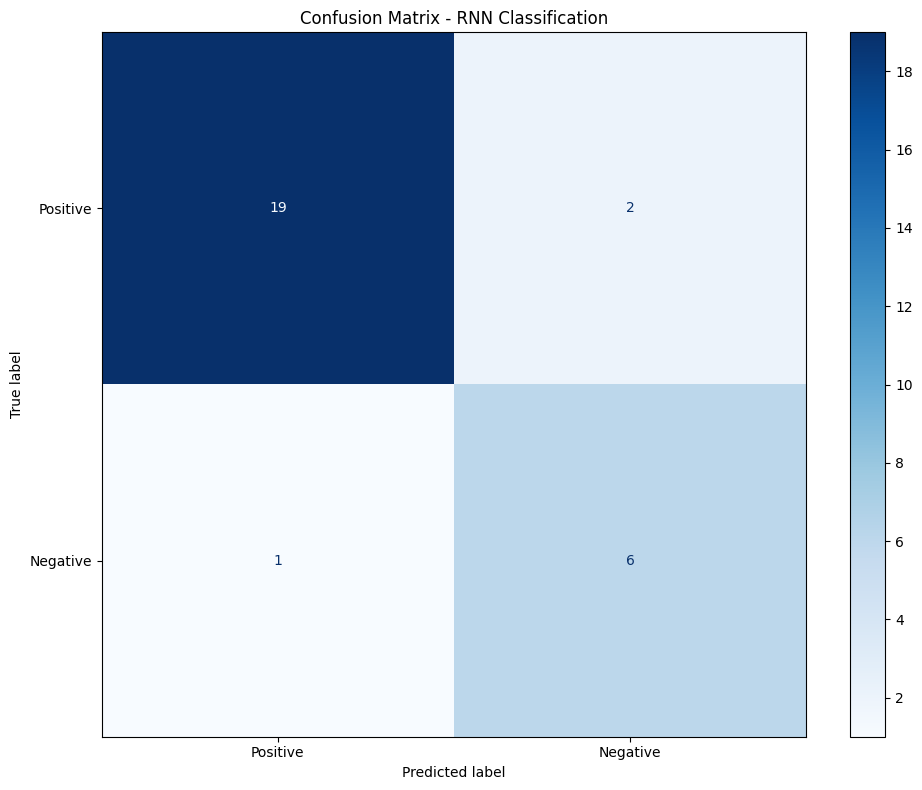

In [ ]:
# ======================== Predicting Classes ======================== #
y_pred = (model_srnn_class_best.predict(X_test_class_pad) > 0.5).astype('int32')

# ======================== Plotting Confusion Matrix ======================== #
cm = confusion_matrix(y_test_class, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Positive', 'Negative'])

# ======================== Plot Configurations ======================== #
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap='Blues')
plt.title("Confusion Matrix - RNN Classification")
plt.grid(False)
plt.tight_layout()
plt.show()

With reference to the output above, we are able to see that the RNN Model performed poorly as seen from the Confusion Matrix where the RNN Model only predicted Positive and did not predict any Negative Sentiments. This determines the model to be voided as the accuracy is only elevated due to the majority of the Test Data being Positive Sentiment.

---
#### 5.1.9.5 Model's Classification Report

In this sub-section, we will be running a Classification Report for the RNN Model performance. This Classification Report will give us insights on the various performance of the RNN Model for each Class instead of just an Overall Test Accuracy. Through this, we can evaluate the performance of the RNN Model on specific classes and also identify any Weak Classes. The formulas for the various metrics are indicated below:

---
**Precision**

Interpretation: Out of all Predicted Positives, how many are Actually Correct?
$$
\text{Precision} = \frac{TP}{TP + FP}
$$

**Where:**
- $TP$: True Positives  
- $FP$: False Positives

---
**Recall**

Interpretation: Out of all Actual Positives, how many did we Correctly Identify?

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

**Where:*
- $TP$: True Positives
- $FN$: False Negatives

---
**F1-Score**

Interpretation: Balances Precision and Recall (useful when Classes are Imbalanced).
$$
F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

---
**Support**

Interpretation: Total Number of Actual Samples in the Class.

$$
\text{Support} = TP + FN
$$

---
**Accuracy**

Interpretation: Overall Correct Predictions Divided by Total Samples.

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

**Where:**
- $TP$: True Positives
- $TN$: True Negatives
- $FP$: False Positives
- $FN$: False Negatives

---
With the relevant formulas listed, we will proceed to produce the Classification Report in the Code Cell below.

In [ ]:
# ======================== Classification Report ======================== #
report_df = pd.DataFrame(classification_report(y_test_class, y_pred, target_names=['Positive', 'Negative'], output_dict=True)).transpose()
report_df.round(4).style.background_gradient(cmap="Blues")

,precision,recall,f1-score,support
Positive,0.950000,0.904800,0.926800,21.000000
Negative,0.750000,0.857100,0.800000,7.000000
accuracy,0.892900,0.892900,0.892900,0.892900
macro avg,0.850000,0.881000,0.863400,28.000000
weighted avg,0.900000,0.892900,0.895100,28.000000


With reference to the output of the DataFrame and the 'F1-Score' Data Column, we are able to see that the F1-Score is somewhat elevated for the Positive Sentiment. However, the Negative Sentiment has a 0 F1-Score which indicates that the only reason for the high accuracy is due to the majority of the Test being Positive Sentiment. Therefore, this model is Voided and should not be used due to the bias.

---
## 5.2 LSTM Classification Model

In this sub-section, we will be training the LSTM Classification Model. Long-Short Term Memory is a type of RNN architecture designed to overcome the vanishing gradient problem in traditional RNN. if this Model does perform well, it can be used as one of the Final Model if Classification is decided to be the chosen method of output. The relevant formulas are indicated below:

---
**Forget Gate**
$$
f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)
$$

Where:
- $f_t$: Forget Gate Vector at Time $t$
- $\sigma$: Sigmoid Activation Function
- $W_f$: Weight Matrix for Forget Gate
- $h_{t-1}$: Previous Hidden State
- $x_t$: Current Input
- $b_f$: Bias for Forget Gate

---
**Input Gate (Activation + Candidate)**
$$
i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)
$$

$$
\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)
$$

Where:
- $i_t$: Input Gate Vector at Time $t$
- $\tilde{C}_t$: Candidate Values for Cell State Update
- $W_i$, $W_C$: Weight Matrices for Input and Cell State
- $b_i$, $b_C$: Biases for Input Gate and Cell Update
- $\tanh$: Hyperbolic Tangent Activation Function

---
**Cell State Update**
$$
C_t = f_t \cdot C_{t-1} + i_t \cdot \tilde{C}_t
$$

Where:
- $C_t$: Updated Cell State at Time $t$
- $C_{t-1}$: Previous Cell State
- $f_t$: Forget Gate Vector
- $i_t$: Input Gate Vector
- $\tilde{C}_t$: Candidate Cell Values

---
**Output Gate and Hidden State**
$$
o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)
$$

$$
h_t = o_t \cdot \tanh(C_t)
$$

Where:
- $o_t$: Output Gate Vector
- $h_t$: Hidden State (also Output of LSTM unit)
- $W_o$: Weight Matrix for Output Gate
- $b_o$: Bias for Output Gate

---

**Output Layer (Classification)**
$$
\hat{y} = \text{softmax}(W_{hy} h_T + b_y)
$$

Where:
- $\hat{y}$: Predicted Class Probabilities (Vector)
- $h_T$: Hidden State at Final Time Step $T$
- $W_{hy}$: Weight Matrix from Hidden to Output
- $b_y$: Output Bias

---
**Loss Function (Sparse Categorical Crossentropy)**
$$
\mathcal{L} = -\log(\hat{y}_{\text{true}})
$$

Where:
- $\mathcal{L}$: Loss for a Single Example
- $\hat{y}_{\text{true}}$: Predicted Probability for the Correct Class
- $\log$: Natural Logarithm


---
With all the essential Formulas for LSTM indicated, we will proceed to the Modeling in this sub-section.

---
### 5.2.1 Defining Callbacks

In this sub-section, we will be pre-defining the various Callbacks. This is to ensure consistency throughout the model and also to increase the Model Accuracy and optimise the Computation Cost for training each model. These Callbacks will be main used during the Keras Tuner in the next sub-section. The formulas and logic for these Callbacks are indicated below:

---
**Learning Rate Scheduler:**

Purpose: Reduces Learning Rate During Training to Fine-tune Model Convergence.

$$\text{If } epoch \mod 10 = 0 \Rightarrow \eta_{new} = \frac{1}{2} \cdot \eta$$

Where:

- $\eta$ = current learning rate

- $\eta_{\text{new}}$ = updated learning rate

- $epoch \bmod 10$ checks if the epoch is a multiple of 10

---
**ReduceLROnPlateau:**

Purpose: Automatically Reduces the Learning Rate when Validation Performance Plateaus.

$$
\text{If no improvement in } val\_loss \text{ for 3 epochs: } \eta_{\text{new}} = 0.5 \cdot \eta
$$

Where:

- $\eta_{\text{new}}$ = reduced learning rate

---
**EarlyStopping:**

Purpose: Prevents Wastage of Computational Power if Model Does Not Improve.

$$
\text{If } val\_loss \text{ does not improve for 10 epochs, stop training and restore best weights}
$$

---
With the formulas and Various Callbacks listed, we will proceed to Defind the Callbacks in the Code Cell below in preparation for Model Training.

In [ ]:
# ======================== Defining Learning Rate Scheduler ======================== #
def scheduler(epoch, lr):
    if epoch % 10 == 0 and epoch:
        return lr * 0.5
    return lr

# ======================== Defining Callbacks ======================== #
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
lr_scheduler = LearningRateScheduler(scheduler)

With reference to the Code Cell above, we are able to identify that that the Callbacks have been successfully defined and the various parameters are set so as to ensure a high accuracy model training.

---
### 5.2.2 Defining Model Parameters

In this sub-section, we will be defining the Model's Parameters that will be tuned using Keras Tuner. There are various Parameters and Characteristics within the Code Cell below. All of these Parameters and their purpose have been indicated below:

---
Embedding Layer
$$
x_t^{(emb)} = E[x_t]
$$
Where:
- $x_t$: token index at time $t$  
- $E$: embedding matrix (learned)

---
Recurrent Hidden State
$$
h_t = \tanh(W_{xh}x_t^{(emb)} + W_{hh}h_{t-1} + b_h)
$$
Where:
- $h_t$: current hidden state  
- $x_t^{(emb)}$: embedded input at time $t$  
- $W_{xh}$: input-to-hidden weights  
- $W_{hh}$: hidden-to-hidden weights  
- $b_h$: hidden bias

---
Dense Layer
$$
z = \text{ReLU}(W_d h_t + b_d)
$$
Where:
- $z$: output of dense hidden layer  
- $W_d$: weights from RNN output to dense  
- $b_d$: bias for dense layer

---
Output Layer (Softmax)
$$
\hat{y} = \text{softmax}(W_o z + b_o)
$$
Where:
- $\hat{y}$: predicted class probabilities  
- $W_o$: weights from dense to output  
- $b_o$: output bias

---
Loss Function (Sparse Categorical Crossentropy)
$$
\mathcal{L} = -\log(\hat{y}_{true})
$$
Where:
- $\hat{y}_{true}$: predicted probability of the true class

---
With all the relevant Formulas indicated, we will proceed to define the Model's Hyperparameter in the Code Cell below.

In [ ]:
def build_lstm_model(hp):
    model = Sequential()

    # ----- Input Layer ----- #
    model.add(Input(shape=(100,)))

    # ----- Embedding Layer ----- #
    model.add(Embedding(
        input_dim=10000,
        output_dim=hp.Choice("embed_dim", [128, 256, 300]),
        embeddings_initializer='uniform'
    ))

    # ----- Bidirectional LSTM Layer 1 ----- #
    model.add(Bidirectional(LSTM(
        units=hp.Choice("lstm_units_1", [128, 256]),
        return_sequences=True,
        activation='tanh',
        kernel_regularizer=l2(0.001)
    )))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_lstm_1", 0.3, 0.5, step=0.1)))

    # ----- Bidirectional LSTM Layer 2 ----- #
    model.add(Bidirectional(LSTM(
        units=hp.Choice("lstm_units_2", [64, 128]),
        return_sequences=False,
        activation='tanh',
        kernel_regularizer=l2(0.001)
    )))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_lstm_2", 0.3, 0.5, step=0.1)))

    # ----- Dense Layer 1 ----- #
    model.add(Dense(
        units=hp.Choice("dense_units_1", [128, 256]),
        kernel_regularizer=l2(0.001)
    ))
    model.add(LeakyReLU(alpha=0.1))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_dense_1", 0.3, 0.5, step=0.1)))

    # ----- Dense Layer 2 ----- #
    model.add(Dense(
        units=hp.Choice("dense_units_2", [64, 128]),
        kernel_regularizer=l2(0.001)
    ))
    model.add(LeakyReLU(alpha=0.1))
    model.add(Dropout(hp.Float("dropout_dense_2", 0.3, 0.5, step=0.1)))

    # ----- Output Layer ----- #
    model.add(Dense(1, activation='sigmoid'))

    # ----- Compile Model ----- #
    model.compile(
        optimizer=Adam(learning_rate=hp.Choice("lr", [5e-4, 1e-4, 5e-5])),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

With reference to the Code Cell above, we are able to confirm that the Function for Creating a New Model for the Classification have been successfully defined and it can be utilised for the Keras Tuner.

---
### 5.2.3 Setting Up Keras Tuner

In this sub-section, we will be setting up the Keras Tuner which will be later utilised to find the best hyperparameter for the RNN Model. Setting up the Keras Tuner appropriately will also ensure that the Random Search do not need to be reruned again as a directory can be set up to link the saved Searches from the Google Drive. This will save up Computational Cost and ensure a more efficient and consistent rerun of Codes should the need arise. To allow for replication, the Seed will be set to 42. However, due to varying Computational Capabilities of different GPUs and/or TPUs, a slight deviation will be normal in the various Evaluation Metrics despite having the same Seed.

In [ ]:
# ======================== Keras Tuner for LSTM ======================== #
tuner_lstm = kt.RandomSearch(
    build_lstm_model,
    objective='val_accuracy',
    max_trials=20,
    executions_per_trial=1,
    directory='Tunings',
    project_name='lstm_classification',
    overwrite=False,
    seed=42
)

Reloading Tuner from Tunings/lstm_classification/tuner0.json


With reference to the Code Cell above, we are able to verify that the Keras Tuner have been established correctly with the directory defined successfully too. We shall move on to conduct the Random Search using the Keras Tuner.

---
### 5.2.4 Conducting Keras Tuner Random Search

In this sub-section, we will be conducting the Random Search to find the best Hyperparameter for the RNN Model using the Keras Tuner. Unlike traditional AIML, there will only be a Random Search and no Grid Search due to the extremely high Computational Resources Require to run a Grid Search for Deep Learning. It is also important to note that the Hyperparameter Random Search will take a long duration due to the nature of the Deep Learning.

In [ ]:
# ======================== Searching Best Hyperparameters ======================== #
tuner_lstm.search(
    X_train_class_pad,
    y_train_class,
    validation_data=(X_val_class_pad, y_val_class),
    epochs=100,
    callbacks=[early_stop, reduce_lr, lr_scheduler],
    verbose=2
)

With reference to the output above, we are able to see that the best Validation Accuracy have been obtained. As the data from the search have been saved, we will not have to rerun the Keras Tuner for this Model again.

---
### 5.2.5 Obtaining Best Hyperparameter

In this sub-section, we will be obtaining the Best Hyperparameter from the Keras Tuner Random Search so as to prepare for the training of the RNN Model in the next sub-section.

In [ ]:
# ======================== Retrieve Best Model ======================== #
best_hp_lstm = tuner_lstm.get_best_hyperparameters(1)[0]
model_lstm_class_best = tuner_lstm.hypermodel.build(best_hp_lstm)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning:

Argument `alpha` is deprecated. Use `negative_slope` instead.



With reference to the Code Cell above, we are able to confirm that the Best Hyperparameter have been obtained and the Model Architecture have been successfully built.

---
### 5.2.6 RNN Model Checkpoint

In this sub-section, we will be establishing the Model Checkpoint and saving the Model to our Google Drive. It is extremely important to take note that we will only be saving the Best Model so as to prevent excessive storage usage. The key monitor that will be used is the Validation Accuracy so as to achieve the Ideal Fit when placed together with the Validation Data. We will also be only saving the Best Model so as to prevent excessive space usage.

In [ ]:
# ======================== Model Checkpointing ======================== #
checkpoint_lstm = ModelCheckpoint(
    filepath="/content/drive/MyDrive/Colab Notebooks/CA1/Models/best_lstm_classification_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False
)

With reference to the Code Cell above, we are able to confirm that the Model have been saved successfully to the Google Drive and the Model is ready for Deployment should the need arise.

---
### 5.2.7 Training of RNN Model

In this sub-section, we will be training the Best RNN Model using the extracted Hyperparameter. This will subsequently allow us to obtain the Model's History which can allow us to conduct various visualisations such as plotting out the Learning Curves to identify the fitting of the Model.

In [ ]:
# ======================== Training Best LSTM Model ======================== #
history_lstm_class = model_lstm_class_best.fit(
    X_train_class_pad, y_train_class,
    validation_data=(X_val_class_pad, y_val_class),
    epochs=100,
    callbacks=[early_stop, reduce_lr, lr_scheduler, checkpoint_lstm],
    verbose=2
)

Epoch 1/100
41/41 - 8s - 183ms/step - accuracy: 0.5406 - loss: 2.4717 - val_accuracy: 0.2500 - val_loss: 2.2744 - learning_rate: 5.0000e-04
Epoch 2/100
41/41 - 1s - 25ms/step - accuracy: 0.6725 - loss: 2.0697 - val_accuracy: 0.2500 - val_loss: 2.2103 - learning_rate: 5.0000e-04
Epoch 3/100
41/41 - 1s - 25ms/step - accuracy: 0.9340 - loss: 1.5036 - val_accuracy: 0.2500 - val_loss: 2.0546 - learning_rate: 5.0000e-04
Epoch 4/100
41/41 - 1s - 31ms/step - accuracy: 0.9939 - loss: 1.2785 - val_accuracy: 0.3929 - val_loss: 1.9674 - learning_rate: 5.0000e-04
Epoch 5/100
41/41 - 1s - 32ms/step - accuracy: 0.9992 - loss: 1.1845 - val_accuracy: 0.8214 - val_loss: 1.6454 - learning_rate: 5.0000e-04
Epoch 6/100
41/41 - 1s - 31ms/step - accuracy: 1.0000 - loss: 1.1121 - val_accuracy: 0.8929 - val_loss: 1.4916 - learning_rate: 5.0000e-04
Epoch 7/100
41/41 - 1s - 25ms/step - accuracy: 0.9992 - loss: 1.0567 - val_accuracy: 0.8929 - val_loss: 1.3371 - learning_rate: 5.0000e-04
Epoch 8/100
41/41 - 1s - 2

With reference to the output of the Code Cell above, we are able to infer that the Sequential Model have been successfully trained and will now be ready for Model Evaluation and Model Deployment on the Test Dataset.

---
### 5.2.8 Saving of Model Weights, Model Architecture and Model Tunings

In this sub-section, we will be Saving the Model's Weights into our Google Drive as per the expectaions of the Assessment. The weight will be saved in 'h5' format and will be submitted. The Tunings Record and the Model Architecture will also be saved so as to prevent the need for re-running all the previous codes which will be extremely Computationally Expensive.

In [ ]:
# ==================== Copy Results Back to Drive ==================== #
model_lstm_class_best.save_weights("Weights/weights_class_lstm_tuned.weights.h5")

shutil.copytree('Tunings',
                os.path.join(DRIVE_ROOT, 'Tunings'),
                dirs_exist_ok=True)

shutil.copytree('Models',
                os.path.join(DRIVE_ROOT, 'Models'),
                dirs_exist_ok=True)

shutil.copytree('Weights',
                os.path.join(DRIVE_ROOT, 'Weights'),
                dirs_exist_ok=True)

'/content/drive/MyDrive/Colab Notebooks/DELE CA1 B/Weights'

With reference to the Code Cell above, we are able to verify that the RNN Model's Weight have been saved successfully to the Google Drive.

---
### 5.2.9 Model Evaluations

In this sub-section, we will be evaluating the RNN Model's Performance on the Movie Reviews. We will not be evaluating solely based of the Model's Accuracy, but also based of it's Learning Curve and Specific Class Accuracy. This is to ensure that the Model is able to perform well at a hollistic level and not just solely based of Accuracy or Class Imbalanced Accuracy. More details will be established for the various Evaluations.

---
#### 5.2.9.1 Plotting of Learning Curve

In this sub-section, we will be plotting the Learning Curve to identify the Learning Capabilities of the RNN Model. This will allow us to identify if the Model is Underfitting, Overfitting or have attained the Ideal Fit. Should the RNN Model be Underfitting, it means that the RNN Model is failing to identify and learn the various patterns of the text. Should the RNN Model be Overfitting, it means that the Model has attained a High Accuracy solely based of Memorising the Data instead of Learning the Data's Attributes. However, if the RNN Model has a Ideal Fit it is a very good indicator that the RNN Model has Learnt from the Training Data. The Potential Observations and subsequent Action Plans are indicated below:

**Under Fitting Learning Curve**
- Re-run Keras Tuner to get Better Hyperparameters
- Adjust the Patience of Early Stopping
- Adjust the Number of Epochs to Obtain Better Learning Rate

**Over Fitting Learning Curve**
- Re-run Keras Tuner to get Better Hyperparameters
- Adjust the Patience of Early Stopping
- Adjust the Number of Epochs to Obtain Better Learning Rate

**Ideal Fitting Learning Curve**
- Accept the Hyperparameter
- Deploy the Model on Testing Data

With the Potential Observations and Action Plan listed, we will proceed to plot out the Learning Curve in the Code Cell below.

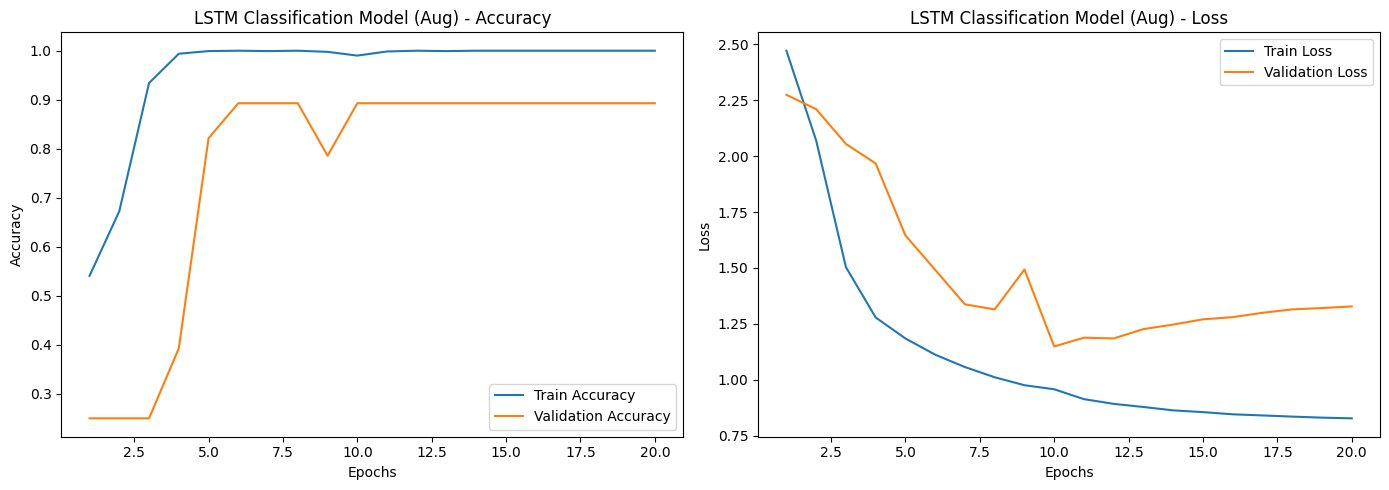

In [ ]:
# ======================== Accuracy & Loss Plot ======================== #
def plot_history(history, title="LSTM Classification Model (Aug)"):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history_lstm_class)

With reference to the output of the Learning Curve above, we are able to see that the RNN Model has achieved a **Ideal Learning Curve**. This means that the RNN Model has indeed learnt from the Training Dataset instead of Memorising or Not Learning at all. With this observation stated, we will now proceed to View the Hyperparameter of the RNN Model and subsequently, Deploy the RNN Model on the Testing Data to get the final Evaluation Metrics.

---
#### 5.2.9.2 Model Hyperparameter

In this sub-section, we will be extracting out the rnn Model's Hyperparameter so as to display the current and Best Hyperparameter for future references within the Project. It is important to take note that the Hyperparameter may be different for other users of the code due to the varying Computational Environment.

In [ ]:
# ======================== Extracting Hyperparameters Into A Dictionary ======================== #
best_hps_dict = best_hp_lstm.values

# ======================== Creating of DataFrame ======================== #
hp_df = pd.DataFrame(list(best_hps_dict.items()), columns=['Hyperparameter', 'Value'])

# ======================== Displaying of DataFrame ======================== #
hp_df.style.background_gradient(cmap="Blues")

,Hyperparameter,Value
0,embed_dim,256.000000
1,lstm_units_1,128.000000
2,dropout_lstm_1,0.500000
3,lstm_units_2,128.000000
4,dropout_lstm_2,0.400000
5,dense_units_1,128.000000
6,dropout_dense_1,0.500000
7,dense_units_2,128.000000
8,dropout_dense_2,0.400000
9,lr,0.000500


With reference to the output of the DataFrame above, we are able to view the various parameters of the RNN Model and we are able to identify the various layers and neurons that makes up the Hidden Layer of the RNN Model.

---
#### 5.2.9.3 Model Deployment on Testing Data

In this sub-section, we will be Deploying our RNN Model on the Testing Data provided. Through the Deployment, we are able to obtain a Test Accuracy Metric and also the Test Loss Metric which will allow us to verify the RNN Model's performance on a Protected Dataset to simulate real-world deployments. The pre-requisite of the Model Performance is evaluated on the following Test Accuracy Threshold:

**Poor**
- Test Accuracy ≤ 50%

**Acceptable**
- Test Accuracy ≥ 50%

**Good**
- Test Accuracy ≥ 65%

**Very Good**
- Test Accuracy ≥ 80%

**Excellent**
- Test Accuracy ≥ 95%

With the threshold for each Performance defined, we will proceed to Deploy the RNN Model in the Code Cell below to determine the Test Accuracy.

In [ ]:
# ======================== Evaluate LSTM Model ======================== #
y_test_class = np.array(y_test_class).astype('int32').reshape(-1)

test_loss_lstm, test_acc_lstm = model_lstm_class_best.evaluate(X_test_class_pad, y_test_class, verbose=2)

results_lstm_df = pd.DataFrame({
    'Metric': ['Test Accuracy', 'Test Loss'],
    'Value': [test_acc_lstm, test_loss_lstm]
})
results_lstm_df.style.background_gradient(cmap="Blues")

1/1 - 1s - 692ms/step - accuracy: 0.8929 - loss: 1.1279


,Metric,Value
0,Test Accuracy,0.892857
1,Test Loss,1.127900


With reference to the output of the DataFrame above, we are able to verify that our RNN Model has achieved a **Very Good** Test Accuracy of 92.8% and also a Relatively Low Test Loss of 0.95. This is a strong indicator that the RNN Model has very good Hyperparameters and will most likely perform well.

---
#### 5.2.9.4 Model's Accuracy Confusion Matrix

In this sub-section, we will be plotting the Confusion Matrix of the RNN Model so as to not only evaluate the Model's Accuracy, but also to identify potential Class Accuracy Weakness and Class Confusion. This will allow us to verify if any actions are required to address these issues and should there be a retuning that needs to be done.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step


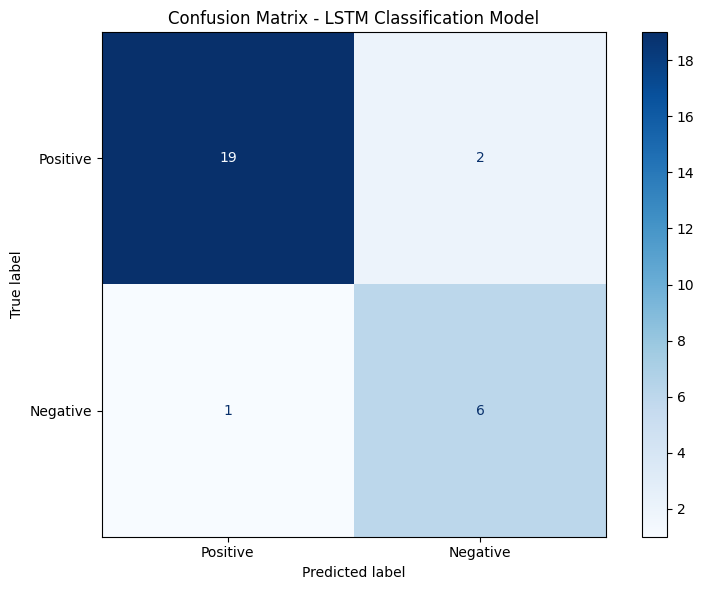

In [ ]:
# ======================== Predict & Compute Confusion Matrix ======================== #
y_pred_lstm = (model_lstm_class_best.predict(X_test_class_pad) > 0.5).astype('int32')

cm_lstm = confusion_matrix(y_test_class, y_pred_lstm)
disp_lstm = ConfusionMatrixDisplay(confusion_matrix=cm_lstm, display_labels=['Positive', 'Negative'])

fig, ax = plt.subplots(figsize=(8, 6))
disp_lstm.plot(ax=ax, cmap='Blues')
plt.title("Confusion Matrix - LSTM Classification Model")
plt.grid(False)
plt.tight_layout()
plt.show()

With reference to the output above, we are able to see that the RNN Model performed perfectly well as seen from the Dark Blue Coloured Squares running from top right to botton left of the Confusion Matrix. However, there are 2 wrong predictions but these do not constitute much to the overall accuracy.

---
#### 5.2.9.5 Model's Classification Report

In this sub-section, we will be running a Classification Report for the RNN Model performance. This Classification Report will give us insights on the various performance of the RNN Model for each Class instead of just an Overall Test Accuracy. Through this, we can evaluate the performance of the RNN Model on specific classes and also identify any Weak Classes. The formulas for the various metrics are indicated below:

---
**Precision**

Interpretation: Out of all Predicted Positives, how many are Actually Correct?
$$
\text{Precision} = \frac{TP}{TP + FP}
$$

**Where:**
- $TP$: True Positives  
- $FP$: False Positives

---
**Recall**

Interpretation: Out of all Actual Positives, how many did we Correctly Identify?

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

**Where:*
- $TP$: True Positives
- $FN$: False Negatives

---
**F1-Score**

Interpretation: Balances Precision and Recall (useful when Classes are Imbalanced).
$$
F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

---
**Support**

Interpretation: Total Number of Actual Samples in the Class.

$$
\text{Support} = TP + FN
$$

---
**Accuracy**

Interpretation: Overall Correct Predictions Divided by Total Samples.

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

**Where:**
- $TP$: True Positives
- $TN$: True Negatives
- $FP$: False Positives
- $FN$: False Negatives

---
With the relevant formulas listed, we will proceed to produce the Classification Report in the Code Cell below.

In [ ]:
# ======================== Generate Classification Report ======================== #
report_lstm = classification_report(
    y_test_class,
    y_pred_lstm,
    target_names=['Positive', 'Negative'],
    output_dict=True
)

report_lstm_df = pd.DataFrame(report_lstm).transpose().round(4)
report_lstm_df.style.background_gradient(cmap="Blues")


,precision,recall,f1-score,support
Positive,0.950000,0.904800,0.926800,21.000000
Negative,0.750000,0.857100,0.800000,7.000000
accuracy,0.892900,0.892900,0.892900,0.892900
macro avg,0.850000,0.881000,0.863400,28.000000
weighted avg,0.900000,0.892900,0.895100,28.000000


With reference to the output of the DataFrame and the 'F1-Score' Data Column, we are able to see that the F1-Score is above 0.85 throughout the Classes This shows that the RNN Model performs extremely well and consistent throughout all the Classes.

---
## 5.3 GRU Classification Model

In this sub-section, we will be training the GRU Classification Model. Gated Recurrent Units (GRUs) are a simplified version of LSTMs that use two gates — the update gate and reset gate — to control the flow of information. They are computationally more efficient than LSTMs while often achieving comparable performance. GRUs do not maintain a separate memory cell like LSTMs, making them easier to train while still addressing the vanishing gradient problem in traditional RNNs. if this Model does perform well, it can be used as one of the Final Model if Classification is decided to be the chosen method of output. The relevant formulas are indicated below:

---
**Reset Gate**
$$
r_t = \sigma(W_r \cdot [h_{t-1}, x_t] + b_r)
$$

Where:  
- $r_t$: Reset Gate  
- $W_r$: Weights for Reset Gate  
- $b_r$: Bias  
- $h_{t-1}$: Previous Hidden State  
- $x_t$: Input at Time $t$  
- $\sigma$: Sigmoid Function

---
**Update Gate**
$$
z_t = \sigma(W_z \cdot [h_{t-1}, x_t] + b_z)
$$

Where:
- $z_t$: Update Gate  
- $W_z$: Weights for Update Gate  
- $b_z$: Bias

---
**Candidate Hidden State**
$$
\tilde{h}_t = \tanh(W_h \cdot [r_t * h_{t-1}, x_t] + b_h)
$$

**Where:**  
- $\tilde{h}_t$: Candidate Hidden State  
- $r_t$: Reset Gate
- $h_{t-1}$: Previous Hidden State  
- $x_t$: Input  
- $W_h$, $b_h$: Weights & Bias  
- $\tanh$: Hyperbolic Tangent Activation

---
**Final Hidden State Update**
$$
h_t = (1 - z_t) * h_{t-1} + z_t * \tilde{h}_t
$$

**Where:**  
- $h_t$: New Hidden State  
- $z_t$: Update Gate
- $\tilde{h}_t$: Candidate State

---

**Output Layer (Softmax)**
$$
\hat{y} = \text{softmax}(W_o h_T + b_o)
$$

**Where:**  
- $h_T$: Last Hidden State
- $\hat{y}$: Predicted Probability for Each Class  
- $W_o$, $b_o$: Output Weights and Bias

---
**Loss Function**
$$
\mathcal{L} = -\log(\hat{y}_{\text{true}})
$$

**Where:**  
- $\hat{y}_{\text{true}}$: Predicted Probability of the Correct Class

---
With all the essential Formulas for GRU indicated, we will proceed to the Modeling in this sub-section.

---
### 5.3.1 Defining Callbacks

In this sub-section, we will be pre-defining the various Callbacks. This is to ensure consistency throughout the model and also to increase the Model Accuracy and optimise the Computation Cost for training each model. These Callbacks will be main used during the Keras Tuner in the next sub-section. The formulas and logic for these Callbacks are indicated below:

---
**Learning Rate Scheduler:**

Purpose: Reduces Learning Rate During Training to Fine-tune Model Convergence.

$$\text{If } epoch \mod 10 = 0 \Rightarrow \eta_{new} = \frac{1}{2} \cdot \eta$$

Where:

- $\eta$ = current learning rate

- $\eta_{\text{new}}$ = updated learning rate

- $epoch \bmod 10$ checks if the epoch is a multiple of 10

---
**ReduceLROnPlateau:**

Purpose: Automatically Reduces the Learning Rate when Validation Performance Plateaus.

$$
\text{If no improvement in } val\_loss \text{ for 3 epochs: } \eta_{\text{new}} = 0.5 \cdot \eta
$$

Where:

- $\eta_{\text{new}}$ = reduced learning rate

---
**EarlyStopping:**

Purpose: Prevents Wastage of Computational Power if Model Does Not Improve.

$$
\text{If } val\_loss \text{ does not improve for 10 epochs, stop training and restore best weights}
$$

---
With the formulas and Various Callbacks listed, we will proceed to Defind the Callbacks in the Code Cell below in preparation for Model Training.

In [ ]:
# ======================== Defining Learning Rate Scheduler ======================== #
def scheduler(epoch, lr):
    if epoch % 10 == 0 and epoch:
        return lr * 0.5
    return lr

# ======================== Defining Callbacks ======================== #
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
lr_scheduler = LearningRateScheduler(scheduler)

With reference to the Code Cell above, we are able to identify that that the Callbacks have been successfully defined and the various parameters are set so as to ensure a high accuracy model training.

---
### 5.3.2 Defining Model Parameters

In this sub-section, we will be defining the Model's Parameters that will be tuned using Keras Tuner. There are various Parameters and Characteristics within the Code Cell below. All of these Parameters and their purpose have been indicated below:

---
Embedding Layer
$$
x_t^{(emb)} = E[x_t]
$$
Where:
- $x_t$: token index at time $t$  
- $E$: embedding matrix (learned)

---
Recurrent Hidden State
$$
h_t = \tanh(W_{xh}x_t^{(emb)} + W_{hh}h_{t-1} + b_h)
$$
Where:
- $h_t$: current hidden state  
- $x_t^{(emb)}$: embedded input at time $t$  
- $W_{xh}$: input-to-hidden weights  
- $W_{hh}$: hidden-to-hidden weights  
- $b_h$: hidden bias

---
Dense Layer
$$
z = \text{ReLU}(W_d h_t + b_d)
$$
Where:
- $z$: output of dense hidden layer  
- $W_d$: weights from RNN output to dense  
- $b_d$: bias for dense layer

---
Output Layer (Softmax)
$$
\hat{y} = \text{softmax}(W_o z + b_o)
$$
Where:
- $\hat{y}$: predicted class probabilities  
- $W_o$: weights from dense to output  
- $b_o$: output bias

---
Loss Function (Sparse Categorical Crossentropy)
$$
\mathcal{L} = -\log(\hat{y}_{true})
$$
Where:
- $\hat{y}_{true}$: predicted probability of the true class

---
With all the relevant Formulas indicated, we will proceed to define the Model's Hyperparameter in the Code Cell below.

In [ ]:
def build_gru_model(hp):
    model = Sequential()

    # ----- Input Layer ----- #
    model.add(Input(shape=(100,)))

    # ----- Embedding Layer ----- #
    model.add(Embedding(
        input_dim=10000,
        output_dim=hp.Choice("embed_dim", [128, 256, 300]),
        embeddings_initializer='uniform'
    ))

    # ----- Bidirectional GRU Layer 1 ----- #
    model.add(Bidirectional(GRU(
        units=hp.Choice("gru_units_1", [128, 256]),
        return_sequences=True,
        activation='tanh',
        kernel_regularizer=l2(0.001)
    )))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_gru_1", 0.3, 0.5, step=0.1)))

    # ----- Bidirectional GRU Layer 2 ----- #
    model.add(Bidirectional(GRU(
        units=hp.Choice("gru_units_2", [64, 128]),
        return_sequences=False,
        activation='tanh',
        kernel_regularizer=l2(0.001)
    )))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_gru_2", 0.3, 0.5, step=0.1)))

    # ----- Dense Layer 1 ----- #
    model.add(Dense(
        units=hp.Choice("dense_units_1", [128, 256]),
        kernel_regularizer=l2(0.001)
    ))
    model.add(LeakyReLU(alpha=0.1))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float("dropout_dense_1", 0.3, 0.5, step=0.1)))

    # ----- Dense Layer 2 ----- #
    model.add(Dense(
        units=hp.Choice("dense_units_2", [64, 128]),
        kernel_regularizer=l2(0.001)
    ))
    model.add(LeakyReLU(alpha=0.1))
    model.add(Dropout(hp.Float("dropout_dense_2", 0.3, 0.5, step=0.1)))

    # ----- Output Layer ----- #
    model.add(Dense(1, activation='sigmoid'))

    # ----- Compile Model ----- #
    model.compile(
        optimizer=Adam(learning_rate=hp.Choice("lr", [5e-4, 1e-4, 5e-5])),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

With reference to the Code Cell above, we are able to confirm that the Function for Creating a New Model for the Classification have been successfully defined and it can be utilised for the Keras Tuner.

---
### 5.3.3 Setting Up Keras Tuner

In this sub-section, we will be setting up the Keras Tuner which will be later utilised to find the best hyperparameter for the RNN Model. Setting up the Keras Tuner appropriately will also ensure that the Random Search do not need to be reruned again as a directory can be set up to link the saved Searches from the Google Drive. This will save up Computational Cost and ensure a more efficient and consistent rerun of Codes should the need arise. To allow for replication, the Seed will be set to 42. However, due to varying Computational Capabilities of different GPUs and/or TPUs, a slight deviation will be normal in the various Evaluation Metrics despite having the same Seed.

In [ ]:
# ======================== Keras Tuner for GRU ======================== #
tuner_gru = kt.RandomSearch(
    build_gru_model,
    objective='val_accuracy',
    max_trials=20,
    executions_per_trial=1,
    directory='Tunings',
    project_name='gru_classification',
    overwrite=False,
    seed=42
)

Reloading Tuner from Tunings/gru_classification/tuner0.json


With reference to the Code Cell above, we are able to verify that the Keras Tuner have been established correctly with the directory defined successfully too. We shall move on to conduct the Random Search using the Keras Tuner.

---
### 5.3.4 Conducting Keras Tuner Random Search

In this sub-section, we will be conducting the Random Search to find the best Hyperparameter for the RNN Model using the Keras Tuner. Unlike traditional AIML, there will only be a Random Search and no Grid Search due to the extremely high Computational Resources Require to run a Grid Search for Deep Learning. It is also important to note that the Hyperparameter Random Search will take a long duration due to the nature of the Deep Learning.

In [ ]:
# ======================== Hyperparameter Search for GRU ======================== #
tuner_gru.search(
    X_train_class_pad,
    y_train_class,
    validation_data=(X_val_class_pad, y_val_class),
    epochs=100,
    callbacks=[early_stop, reduce_lr, lr_scheduler],
    verbose=2
)

With reference to the output above, we are able to see that the best Validation Accuracy have been obtained. As the data from the search have been saved, we will not have to rerun the Keras Tuner for this Model again.

---
### 5.3.5 Obtaining Best Hyperparameter

In this sub-section, we will be obtaining the Best Hyperparameter from the Keras Tuner Random Search so as to prepare for the training of the RNN Model in the next sub-section.

In [ ]:
# ======================== Retrieve Best GRU Model ======================== #
best_hp_gru = tuner_gru.get_best_hyperparameters(1)[0]
model_gru_class_best = tuner_gru.hypermodel.build(best_hp_gru)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning:

Argument `alpha` is deprecated. Use `negative_slope` instead.



With reference to the Code Cell above, we are able to confirm that the Best Hyperparameter have been obtained and the Model Architecture have been successfully built.

---
### 5.3.6 RNN Model Checkpoint

In this sub-section, we will be establishing the Model Checkpoint and saving the Model to our Google Drive. It is extremely important to take note that we will only be saving the Best Model so as to prevent excessive storage usage. The key monitor that will be used is the Validation Accuracy so as to achieve the Ideal Fit when placed together with the Validation Data. We will also be only saving the Best Model so as to prevent excessive space usage.

In [ ]:
# ======================== Model Checkpointing ======================== #
checkpoint_gru = ModelCheckpoint(
    filepath="/content/drive/MyDrive/Colab Notebooks/CA1/Models/best_gru_classification_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False
)

With reference to the Code Cell above, we are able to confirm that the Model have been saved successfully to the Google Drive and the Model is ready for Deployment should the need arise.

---
### 5.3.7 Training of RNN Model

In this sub-section, we will be training the Best RNN Model using the extracted Hyperparameter. This will subsequently allow us to obtain the Model's History which can allow us to conduct various visualisations such as plotting out the Learning Curves to identify the fitting of the Model.

In [ ]:
# ======================== Training GRU Model ======================== #
history_gru_class = model_gru_class_best.fit(
    X_train_class_pad, y_train_class,
    validation_data=(X_val_class_pad, y_val_class),
    epochs=100,
    callbacks=[early_stop, reduce_lr, lr_scheduler, checkpoint_gru],
    verbose=2
)

Epoch 1/100
41/41 - 9s - 227ms/step - accuracy: 0.5184 - loss: 2.4815 - val_accuracy: 0.2500 - val_loss: 2.2600 - learning_rate: 1.0000e-04
Epoch 2/100
41/41 - 1s - 25ms/step - accuracy: 0.5836 - loss: 2.2816 - val_accuracy: 0.2500 - val_loss: 2.2045 - learning_rate: 1.0000e-04
Epoch 3/100
41/41 - 1s - 24ms/step - accuracy: 0.6342 - loss: 2.1475 - val_accuracy: 0.2500 - val_loss: 2.1540 - learning_rate: 1.0000e-04
Epoch 4/100
41/41 - 1s - 24ms/step - accuracy: 0.6518 - loss: 2.0427 - val_accuracy: 0.2500 - val_loss: 2.1102 - learning_rate: 1.0000e-04
Epoch 5/100
41/41 - 1s - 25ms/step - accuracy: 0.7147 - loss: 1.8666 - val_accuracy: 0.2500 - val_loss: 2.0689 - learning_rate: 1.0000e-04
Epoch 6/100
41/41 - 1s - 24ms/step - accuracy: 0.7554 - loss: 1.7624 - val_accuracy: 0.2500 - val_loss: 1.9956 - learning_rate: 1.0000e-04
Epoch 7/100
41/41 - 1s - 31ms/step - accuracy: 0.8535 - loss: 1.5745 - val_accuracy: 0.3929 - val_loss: 1.8858 - learning_rate: 1.0000e-04
Epoch 8/100
41/41 - 1s - 3

With reference to the output of the Code Cell above, we are able to infer that the Sequential Model have been successfully trained and will now be ready for Model Evaluation and Model Deployment on the Test Dataset.

---
### 5.3.8 Saving of Model Weights, Model Architecture and Model Tunings

In this sub-section, we will be Saving the Model's Weights into our Google Drive as per the expectaions of the Assessment. The weight will be saved in 'h5' format and will be submitted. The Tunings Record and the Model Architecture will also be saved so as to prevent the need for re-running all the previous codes which will be extremely Computationally Expensive.

In [ ]:
# ==================== Copy Results Back to Drive ==================== #
model_gru_class_best.save_weights("Weights/weights_class_gru_tuned.weights.h5")

shutil.copytree('Tunings',
                os.path.join(DRIVE_ROOT, 'Tunings'),
                dirs_exist_ok=True)

shutil.copytree('Models',
                os.path.join(DRIVE_ROOT, 'Models'),
                dirs_exist_ok=True)

shutil.copytree('Weights',
                os.path.join(DRIVE_ROOT, 'Weights'),
                dirs_exist_ok=True)

'/content/drive/MyDrive/Colab Notebooks/DELE CA1 B/Weights'

With reference to the Code Cell above, we are able to verify that the RNN Model's Weight have been saved successfully to the Google Drive.

---
### 5.3.9 Model Evaluations

In this sub-section, we will be evaluating the RNN Model's Performance on the Movie Reviews. We will not be evaluating solely based of the Model's Accuracy, but also based of it's Learning Curve and Specific Class Accuracy. This is to ensure that the Model is able to perform well at a hollistic level and not just solely based of Accuracy or Class Imbalanced Accuracy. More details will be established for the various Evaluations.

---
#### 5.3.9.1 Plotting of Learning Curve

In this sub-section, we will be plotting the Learning Curve to identify the Learning Capabilities of the RNN Model. This will allow us to identify if the Model is Underfitting, Overfitting or have attained the Ideal Fit. Should the RNN Model be Underfitting, it means that the RNN Model is failing to identify and learn the various patterns of the text. Should the RNN Model be Overfitting, it means that the Model has attained a High Accuracy solely based of Memorising the Data instead of Learning the Data's Attributes. However, if the RNN Model has a Ideal Fit it is a very good indicator that the RNN Model has Learnt from the Training Data. The Potential Observations and subsequent Action Plans are indicated below:

**Under Fitting Learning Curve**
- Re-run Keras Tuner to get Better Hyperparameters
- Adjust the Patience of Early Stopping
- Adjust the Number of Epochs to Obtain Better Learning Rate

**Over Fitting Learning Curve**
- Re-run Keras Tuner to get Better Hyperparameters
- Adjust the Patience of Early Stopping
- Adjust the Number of Epochs to Obtain Better Learning Rate

**Ideal Fitting Learning Curve**
- Accept the Hyperparameter
- Deploy the Model on Testing Data

With the Potential Observations and Action Plan listed, we will proceed to plot out the Learning Curve in the Code Cell below.

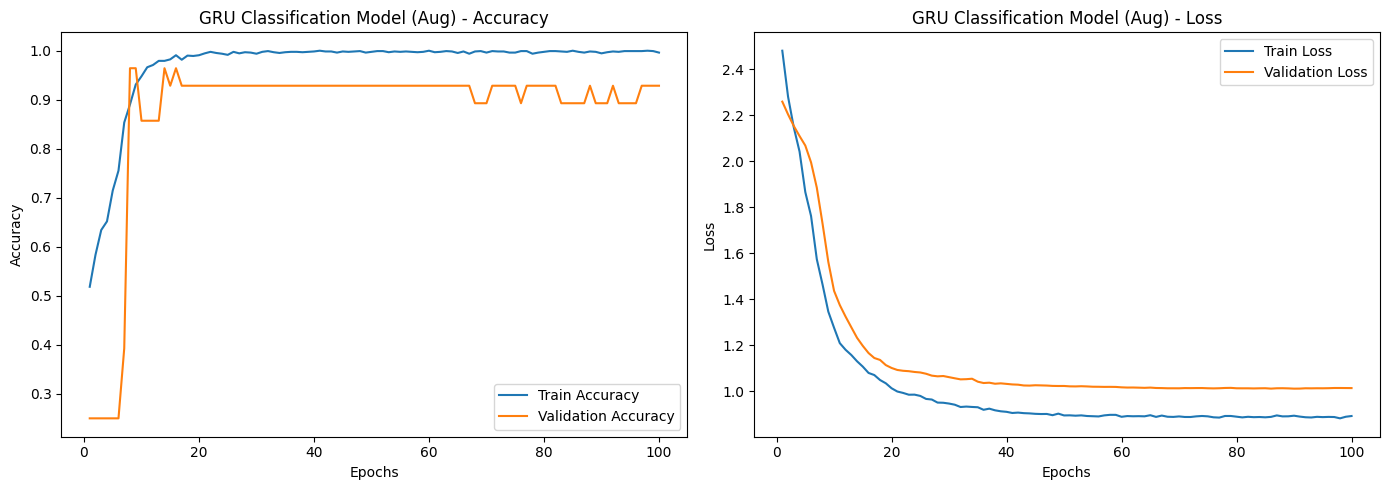

In [ ]:
# ======================== Accuracy & Loss Plot ======================== #
def plot_history(history, title="GRU Classification Model (Aug)"):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history_gru_class)

With reference to the output of the Learning Curve above, we are able to see that the RNN Model has achieved a **Ideal Learning Curve**. This means that the RNN Model has indeed learnt from the Training Dataset instead of Memorising or Not Learning at all. With this observation stated, we will now proceed to View the Hyperparameter of the RNN Model and subsequently, Deploy the RNN Model on the Testing Data to get the final Evaluation Metrics.

---
#### 5.3.9.2 Model Hyperparameter

In this sub-section, we will be extracting out the rnn Model's Hyperparameter so as to display the current and Best Hyperparameter for future references within the Project. It is important to take note that the Hyperparameter may be different for other users of the code due to the varying Computational Environment.

In [ ]:
# ======================== Extracting Hyperparameters Into A Dictionary ======================== #
best_hps_dict = best_hp_gru.values

# ======================== Creating of DataFrame ======================== #
hp_df = pd.DataFrame(list(best_hps_dict.items()), columns=['Hyperparameter', 'Value'])

# ======================== Displaying of DataFrame ======================== #
hp_df.style.background_gradient(cmap="Blues")

,Hyperparameter,Value
0,embed_dim,300.000000
1,gru_units_1,256.000000
2,dropout_gru_1,0.500000
3,gru_units_2,64.000000
4,dropout_gru_2,0.500000
5,dense_units_1,128.000000
6,dropout_dense_1,0.400000
7,dense_units_2,64.000000
8,dropout_dense_2,0.300000
9,lr,0.000100


With reference to the output of the DataFrame above, we are able to view the various parameters of the RNN Model and we are able to identify the various layers and neurons that makes up the Hidden Layer of the RNN Model.

---
#### 5.3.9.3 Model Deployment on Testing Data

In this sub-section, we will be Deploying our RNN Model on the Testing Data provided. Through the Deployment, we are able to obtain a Test Accuracy Metric and also the Test Loss Metric which will allow us to verify the RNN Model's performance on a Protected Dataset to simulate real-world deployments. The pre-requisite of the Model Performance is evaluated on the following Test Accuracy Threshold:

**Poor**
- Test Accuracy ≤ 50%

**Acceptable**
- Test Accuracy ≥ 50%

**Good**
- Test Accuracy ≥ 65%

**Very Good**
- Test Accuracy ≥ 80%

**Excellent**
- Test Accuracy ≥ 95%

With the threshold for each Performance defined, we will proceed to Deploy the RNN Model in the Code Cell below to determine the Test Accuracy.

In [ ]:
# ======================== Evaluate LSTM Model ======================== #
y_test_class = np.array(y_test_class).astype('int32').reshape(-1)

test_loss_gru, test_acc_gru = model_gru_class_best.evaluate(X_test_class_pad, y_test_class, verbose=2)

results_gru_df = pd.DataFrame({
    'Metric': ['Test Accuracy', 'Test Loss'],
    'Value': [test_acc_gru, test_loss_gru]
})
results_gru_df.style.background_gradient(cmap="Blues")

1/1 - 1s - 653ms/step - accuracy: 0.9643 - loss: 1.0550


,Metric,Value
0,Test Accuracy,0.964286
1,Test Loss,1.055028


With reference to the output of the DataFrame above, we are able to verify that our RNN Model has achieved a **Excellent** Test Accuracy of 96.4% and also a Relatively Low Test Loss of 1.055. This is a strong indicator that the RNN Model has very good Hyperparameters and will most likely perform well.

---
#### 5.3.9.4 Model's Accuracy Confusion Matrix

In this sub-section, we will be plotting the Confusion Matrix of the RNN Model so as to not only evaluate the Model's Accuracy, but also to identify potential Class Accuracy Weakness and Class Confusion. This will allow us to verify if any actions are required to address these issues and should there be a retuning that needs to be done.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step


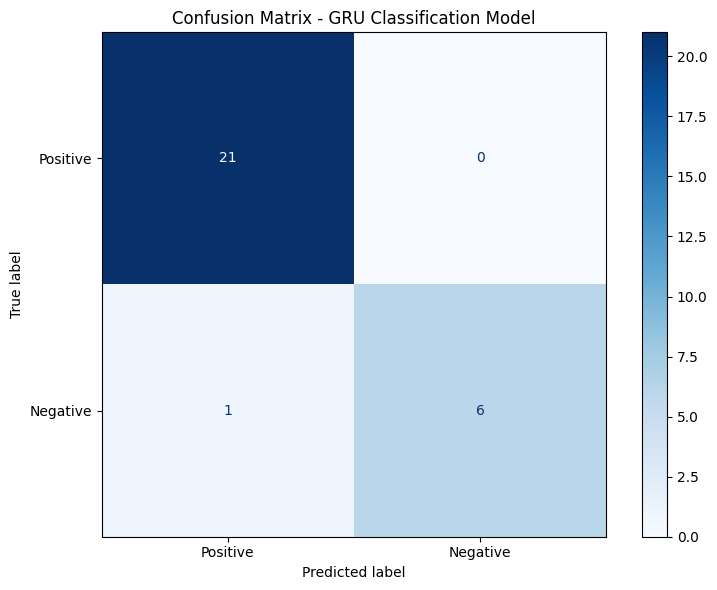

In [ ]:
# ======================== Predict & Confusion Matrix ======================== #
y_pred_gru = (model_gru_class_best.predict(X_test_class_pad) > 0.5).astype('int32')

cm_gru = confusion_matrix(y_test_class, y_pred_gru)
disp_gru = ConfusionMatrixDisplay(confusion_matrix=cm_gru, display_labels=['Positive', 'Negative'])

fig, ax = plt.subplots(figsize=(8, 6))
disp_gru.plot(ax=ax, cmap='Blues')
plt.title("Confusion Matrix - GRU Classification Model")
plt.grid(False)
plt.tight_layout()
plt.show()

With reference to the output above, we are able to see that the RNN Model performed perfectly well as seen from the Dark Blue Coloured Squares running from top right to botton left of the Confusion Matrix. However, there are 2 wrong predictions but these do not constitute much to the overall accuracy.

---
#### 5.3.9.5 Model's Classification Report

In this sub-section, we will be running a Classification Report for the RNN Model performance. This Classification Report will give us insights on the various performance of the RNN Model for each Class instead of just an Overall Test Accuracy. Through this, we can evaluate the performance of the RNN Model on specific classes and also identify any Weak Classes. The formulas for the various metrics are indicated below:

---
**Precision**

Interpretation: Out of all Predicted Positives, how many are Actually Correct?
$$
\text{Precision} = \frac{TP}{TP + FP}
$$

**Where:**
- $TP$: True Positives  
- $FP$: False Positives

---
**Recall**

Interpretation: Out of all Actual Positives, how many did we Correctly Identify?

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

**Where:*
- $TP$: True Positives
- $FN$: False Negatives

---
**F1-Score**

Interpretation: Balances Precision and Recall (useful when Classes are Imbalanced).
$$
F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

---
**Support**

Interpretation: Total Number of Actual Samples in the Class.

$$
\text{Support} = TP + FN
$$

---
**Accuracy**

Interpretation: Overall Correct Predictions Divided by Total Samples.

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

**Where:**
- $TP$: True Positives
- $TN$: True Negatives
- $FP$: False Positives
- $FN$: False Negatives

---
With the relevant formulas listed, we will proceed to produce the Classification Report in the Code Cell below.

In [ ]:
# ======================== Classification Report ======================== #
report_gru = classification_report(
    y_test_class,
    y_pred_gru,
    target_names=['Positive', 'Negative'],
    output_dict=True
)

report_gru_df = pd.DataFrame(report_gru).transpose().round(4)
report_gru_df.style.background_gradient(cmap="Blues")

,precision,recall,f1-score,support
Positive,0.954500,1.000000,0.976700,21.000000
Negative,1.000000,0.857100,0.923100,7.000000
accuracy,0.964300,0.964300,0.964300,0.964300
macro avg,0.977300,0.928600,0.949900,28.000000
weighted avg,0.965900,0.964300,0.963300,28.000000


With reference to the output of the DataFrame and the 'F1-Score' Data Column, we are able to see that the F1-Score is above 0.90 throughout the Classes This shows that the RNN Model performs extremely well and consistent throughout all the Classes.